>Hello! My name is [Mauricio Ruanova](https://mruanova.com) and I am following the [Decision Making](https://en.wikipedia.org/wiki/Decision-making) process.

![Titanic](https://mruanova.com/leo.jpg)

Table of Contents
1. [Step 1 - Identify The Problem](#step1)
1. [Step 2 - Explore Your Options](#step2)
1. [Step 3 - Evaluate The Outcomes](#step3)
1. [Step 4 - Decide And Act](#step4)
1. [Change Log](#changelog)
1. [Credits](#credits)

<a id="step1"></a>
# Step 1 Identify The Problem
In this problem we have a clear goal: to predict survival on the Titanic,
using [Exploratory Data Analysis](https://en.wikipedia.org/wiki/Exploratory_data_analysis) 
and [Machine Learning](https://en.wikipedia.org/wiki/Machine_learning).

**How-to use the Titanic data set:** Please take a look at the [Data Dictionary](https://www.kaggle.com/c/titanic/data)

## Background Information
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg.

Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we were asked to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

### Data used in this competition

I am using two similar datasets that include passenger information like name, age, gender, socio-economic class, etc. One dataset is titled `train.csv` and the other is titled `test.csv`.

Train.csv contains the details of a subset of the passengers on board (891 to be exact) and reveals whether they survived or not, also known as the “ground truth”.

The `test.csv` dataset contains similar information but does not disclose the “ground truth” for each passenger. It’s used to predict these outcomes.

### Submission

Generated a prediction file `my_submission.csv` and submitted my prediction to the Kaggle competition to get a score in the leaderboard.

In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python

#load packages
import sys #access to system parameters https://docs.python.org/3/library/sys.html
print("Python version: {}". format(sys.version))

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
print("pandas version: {}". format(pd.__version__))

import matplotlib #collection of functions for scientific and publication-ready visualization
print("matplotlib version: {}". format(matplotlib.__version__))

import numpy as np # linear algebra
print("NumPy version: {}". format(np.__version__))

import scipy as sp #collection of functions for scientific computing and advance mathematics
print("SciPy version: {}". format(sp.__version__)) 

import IPython
from IPython import display #pretty printing of dataframes in Jupyter notebook
print("IPython version: {}". format(IPython.__version__)) 

import sklearn #collection of machine learning algorithms
print("scikit-learn version: {}". format(sklearn.__version__))

#misc libraries
import random
import time


#ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

# Any results you write to the current directory are saved as output.

Python version: 3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) 
[GCC 7.3.0]
pandas version: 1.1.0
matplotlib version: 3.2.1
NumPy version: 1.18.5
SciPy version: 1.4.1
IPython version: 7.13.0
scikit-learn version: 0.23.2
titanic



In [52]:
from pandas import Series,DataFrame
from matplotlib import style
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')
# machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

train_data = pd.read_csv("../input/titanic/train.csv")
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [53]:
train_data.shape # 891

(891, 12)

In [54]:
test_data = pd.read_csv("../input/titanic/test.csv")
test_data.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [55]:
test_data.shape # 418

(418, 11)

### Missing Values by column

In [56]:
# train_data.info()
# train_data.describe()
# total = train_data.isnull().sum().sort_values(ascending=False)
# percent_1 = train_data.isnull().sum()/train_data.isnull().count()*100
# percent_2 = (round(percent_1, 1)).sort_values(ascending=False)
# missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
# missing_data

print(pd.isnull(train_data).sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [57]:
print(pd.isnull(test_data).sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### PassengerId, Name, Ticket

In [58]:
# drop unnecessary columns, these columns won't be useful in analysis and prediction
train_data = train_data.drop(['PassengerId','Name','Ticket'],axis=1)
train_data.head()
test_data = test_data.drop(['Name','Ticket'],axis=1)
test_data.tail()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
413,1305,3,male,NaN,0,0,8.0500,NaN,S
414,1306,1,female,39.0,0,0,108.9000,C105,C
415,1307,3,male,38.5,0,0,7.2500,NaN,S
416,1308,3,male,NaN,0,0,8.0500,NaN,S
417,1309,3,male,NaN,1,1,22.3583,NaN,C


### New column: Not Alone

In [59]:
# visualization

#data = [train_data, test_data]
#for dataset in data:
#    dataset['relatives'] = dataset['SibSp'] + dataset['Parch']
#    dataset.loc[dataset['relatives'] > 0, 'not_alone'] = 0
#    dataset.loc[dataset['relatives'] == 0, 'not_alone'] = 1
#    dataset['not_alone'] = dataset['not_alone'].astype(int)
#train_data['not_alone'].value_counts()

### Embarked

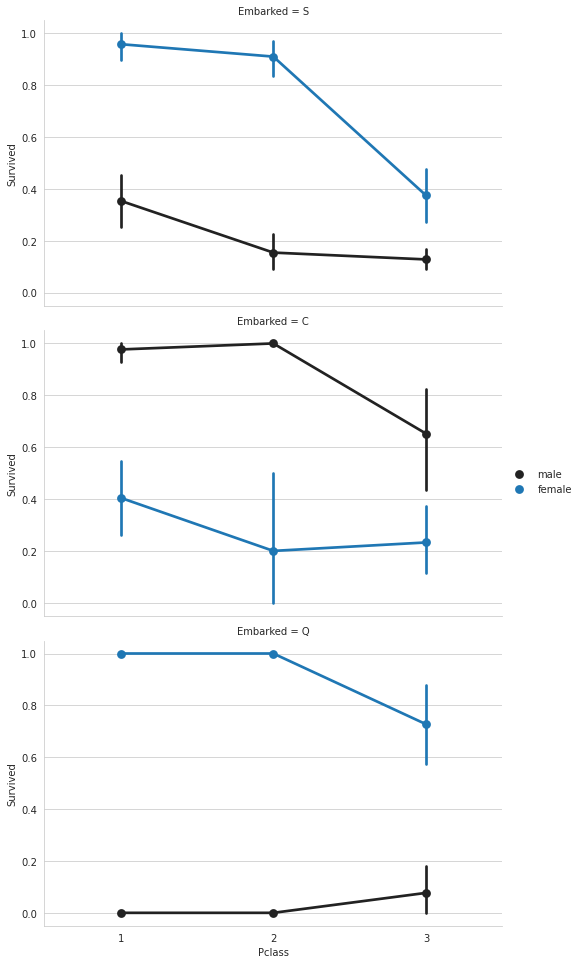

In [60]:
# visualization
FacetGrid = sns.FacetGrid(train_data, row='Embarked', height=4.5, aspect=1.6)
FacetGrid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette=None,  order=None, hue_order=None )
FacetGrid.add_legend()

In [61]:
# only in train data, fill the two missing values with the most occurred value, which is "S".
train_data["Embarked"] = train_data["Embarked"].fillna("S")

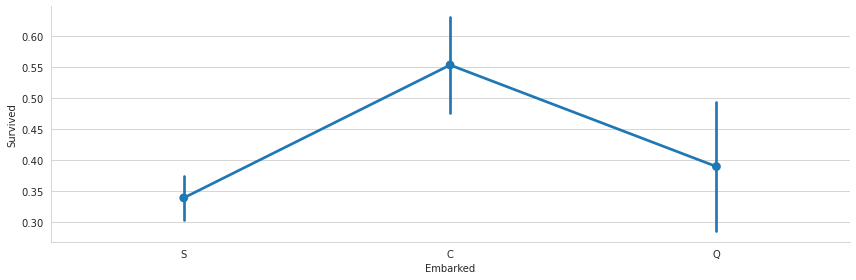

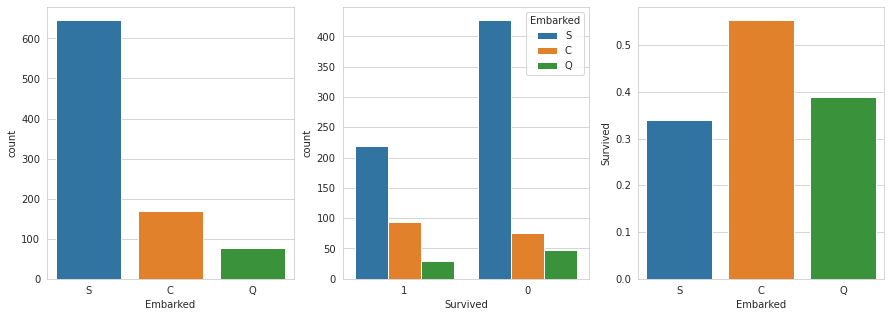

In [62]:
# plot
sns.factorplot('Embarked','Survived', data=train_data,size=4,aspect=3)
fig, (axis1,axis2,axis3) = plt.subplots(1,3,figsize=(15,5))
sns.countplot(x='Embarked', data=train_data, ax=axis1)
sns.countplot(x='Survived', hue="Embarked", data=train_data, order=[1,0], ax=axis2)
# group by embarked, and get the mean for survived passengers for each value in Embarked
embark_perc = train_data[["Embarked", "Survived"]].groupby(['Embarked'],as_index=False).mean()
sns.barplot(x='Embarked', y='Survived', data=embark_perc,order=['S','C','Q'],ax=axis3)
# Either to consider Embarked column in predictions,
# and remove "S" dummy variable, 
# and leave "C" & "Q", since they seem to have a good rate for Survival.
# OR, don't create dummy variables for Embarked column, just drop it, 
# because logically, Embarked doesn't seem to be useful in prediction.
embark_dummies_titanic  = pd.get_dummies(train_data['Embarked'])
embark_dummies_titanic.drop(['S'], axis=1, inplace=True)
embark_dummies_test  = pd.get_dummies(test_data['Embarked'])
embark_dummies_test.drop(['S'], axis=1, inplace=True)
train_data = train_data.join(embark_dummies_titanic)
test_data = test_data.join(embark_dummies_test)
train_data.drop(['Embarked'], axis=1,inplace=True)
test_data.drop(['Embarked'], axis=1,inplace=True)

### Fare

In [63]:
# only for test data, since there is a missing "Fare" values
test_data["Fare"].fillna(test_data["Fare"].median(), inplace=True)

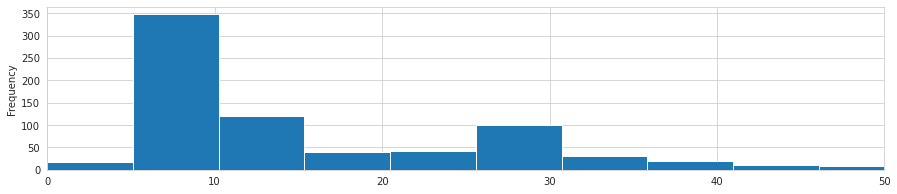

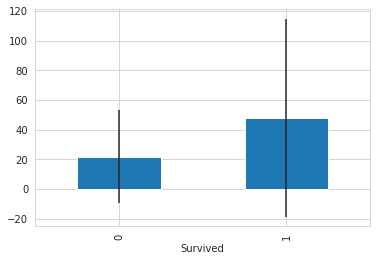

In [64]:
# convert from float to int
train_data['Fare'] = train_data['Fare'].astype(int)
test_data['Fare'] = test_data['Fare'].astype(int)

# get fare for survived & didn't survive passengers 
fare_not_survived = train_data["Fare"][train_data["Survived"] == 0]
fare_survived = train_data["Fare"][train_data["Survived"] == 1]

# get average and std for fare of survived/not survived passengers
avgerage_fare = DataFrame([fare_not_survived.mean(), fare_survived.mean()])
std_fare = DataFrame([fare_not_survived.std(), fare_survived.std()])

# plot
train_data['Fare'].plot(kind='hist', figsize=(15,3),bins=100, xlim=(0,50))

avgerage_fare.index.names = std_fare.index.names = ["Survived"]
avgerage_fare.plot(yerr=std_fare,kind='bar',legend=False)

### Age

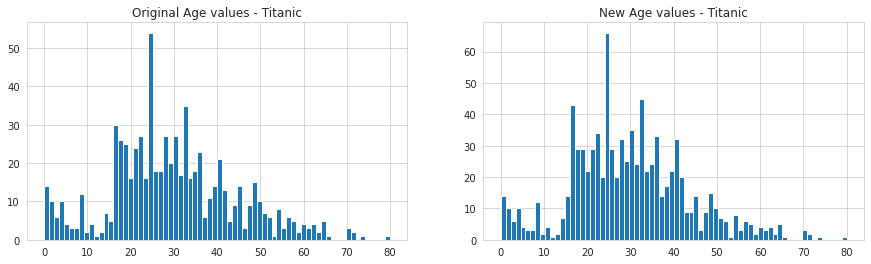

In [65]:
fig, (axis1,axis2) = plt.subplots(1,2,figsize=(15,4))
axis1.set_title('Original Age values - Titanic')
axis2.set_title('New Age values - Titanic')

# get average, std, and number of NaN values in train data
avg_age_train = train_data["Age"].mean()
std_age_train = train_data["Age"].std()
count_nan_age_train = train_data["Age"].isnull().sum()

# get average, std, and number of NaN values in test data
avg_age_test = test_data["Age"].mean()
std_age_test = test_data["Age"].std()
count_nan_age_test = test_data["Age"].isnull().sum()

# generate random numbers between (mean - std) & (mean + std)
rand_1 = np.random.randint(avg_age_train - std_age_train, avg_age_train + std_age_train, size = count_nan_age_train)
rand_2 = np.random.randint(avg_age_test - std_age_test, avg_age_test + std_age_test, size = count_nan_age_test)

# plot original Age values
# NOTE: drop all null values, and convert to int
train_data['Age'].dropna().astype(int).hist(bins=70, ax=axis1)
# test_data['Age'].dropna().astype(int).hist(bins=70, ax=axis1)

# fill NaN values in Age column with random values generated
train_data["Age"][np.isnan(train_data["Age"])] = rand_1
test_data["Age"][np.isnan(test_data["Age"])] = rand_2

# convert from float to int
train_data['Age'] = train_data['Age'].astype(int)
test_data['Age'] = test_data['Age'].astype(int)

# plot new Age Values
train_data['Age'].hist(bins=70, ax=axis2)
# test_data['Age'].hist(bins=70, ax=axis4)

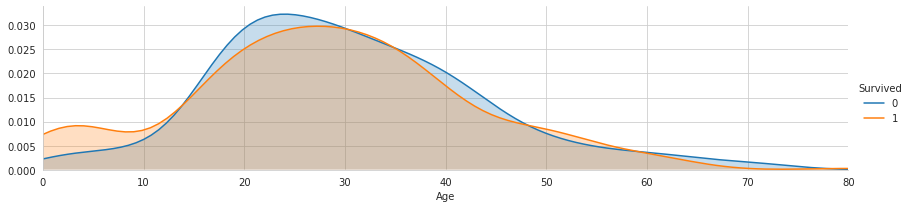

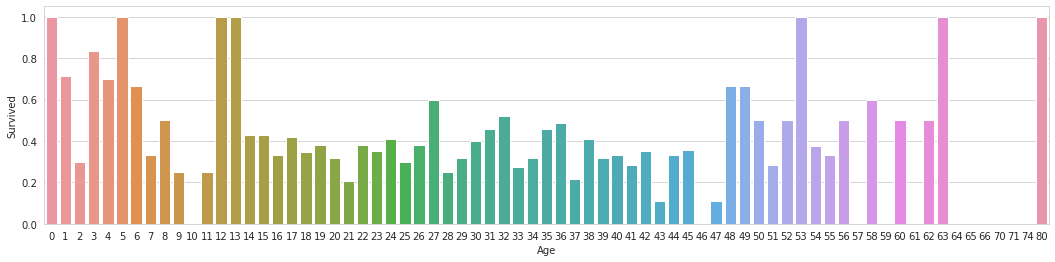

In [66]:
# .... continue with plot Age column

# peaks for survived/not survived passengers by their age
facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'Age',shade= True)
facet.set(xlim=(0, train_data['Age'].max()))
facet.add_legend()

# average survived passengers by age
fig, axis1 = plt.subplots(1,1,figsize=(18,4))
average_age = train_data[["Age", "Survived"]].groupby(['Age'],as_index=False).mean()
sns.barplot(x='Age', y='Survived', data=average_age)

### Cabin

In [67]:
train_data.drop(['Cabin'],axis=1,inplace=True)
train_data.head()
test_data.drop(['Cabin'],axis=1,inplace=True)
test_data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q
0,892,3,male,34,0,0,7,0,1
1,893,3,female,47,1,0,7,0,0
2,894,2,male,62,0,0,9,0,1
3,895,3,male,27,0,0,8,0,0
4,896,3,female,22,1,1,12,0,0


### Family

[Text(0, 0, 'With Family'), Text(0, 0, 'Alone')]

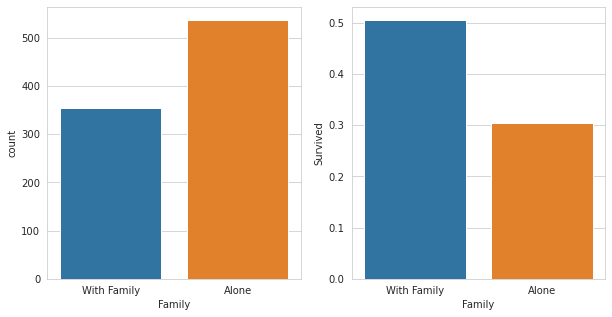

In [68]:
# Family

# Instead of having two columns Parch & SibSp, 
# we can have only one column represent if the passenger had any family member aboard or not,
# Meaning, if having any family member(whether parent, brother, ...etc) will increase chances of Survival or not.
train_data['Family'] =  train_data["Parch"] + train_data["SibSp"]
train_data['Family'].loc[train_data['Family'] > 0] = 1
train_data['Family'].loc[train_data['Family'] == 0] = 0

test_data['Family'] = test_data["Parch"] + test_data["SibSp"]
test_data['Family'].loc[test_data['Family'] > 0] = 1
test_data['Family'].loc[test_data['Family'] == 0] = 0

# drop Parch & SibSp
train_data = train_data.drop(['SibSp','Parch'], axis=1)
test_data = test_data.drop(['SibSp','Parch'], axis=1)

# plot
fig, (axis1,axis2) = plt.subplots(1,2,sharex=True,figsize=(10,5))
sns.countplot(x='Family', data=train_data, order=[1,0], ax=axis1)

# average of survived for those who had/didn't have any family member
family_perc = train_data[["Family", "Survived"]].groupby(['Family'],as_index=False).mean()
sns.barplot(x='Family', y='Survived', data=family_perc, order=[1,0], ax=axis2)

axis1.set_xticklabels(["With Family","Alone"], rotation=0)

### Sex

Text(0.5, 1.0, 'Male')

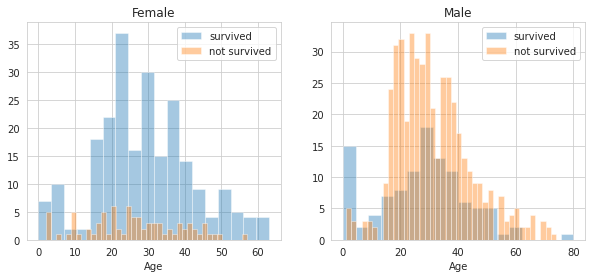

In [69]:
# visualization
survived = 'survived'
not_survived = 'not survived'
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10, 4))
women = train_data[train_data['Sex']=='female']
men = train_data[train_data['Sex']=='male']
ax = sns.distplot(women[women['Survived']==1].Age.dropna(), bins=18, label = survived, ax = axes[0], kde = False)
ax = sns.distplot(women[women['Survived']==0].Age.dropna(), bins=40, label = not_survived, ax = axes[0], kde = False)
ax.legend()
ax.set_title('Female')
ax = sns.distplot(men[men['Survived']==1].Age.dropna(), bins=18, label = survived, ax = axes[1], kde = False)
ax = sns.distplot(men[men['Survived']==0].Age.dropna(), bins=40, label = not_survived, ax = axes[1], kde = False)
ax.legend() 
ax.set_title('Male')

In [70]:
# % of women who survived: train
women = train_data.loc[train_data.Sex == 'female']["Survived"]
if len(women) > 0 :
    rate_women = sum(women)/len(women)
print("% of women who survived:", rate_women)

# % of men who survived: train
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = 0
if len(men) > 0 :
    rate_men = sum(men)/len(men)
print("% of men who survived:", rate_men)

% of women who survived: 0.7420382165605095
% of men who survived: 0.18890814558058924


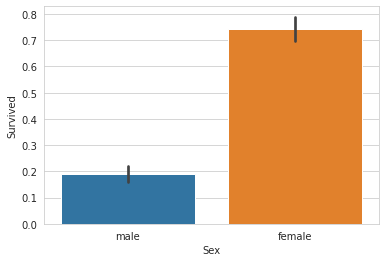

In [71]:
sns.barplot(x='Sex', y='Survived', data=train_data)

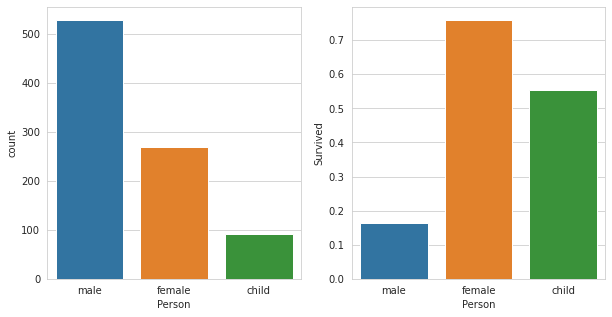

In [72]:
# Sex

# As we see, children(age < ~16) on aboard seem to have a high chances for Survival.
# So, we can classify passengers as males, females, and child
def get_person(passenger):
    age,sex = passenger
    return 'child' if age < 16 else sex
    
train_data['Person'] = train_data[['Age','Sex']].apply(get_person,axis=1)
test_data['Person'] = test_data[['Age','Sex']].apply(get_person,axis=1)

# No need to use Sex column since we created Person column
train_data.drop(['Sex'],axis=1,inplace=True)
test_data.drop(['Sex'],axis=1,inplace=True)

# create dummy variables for Person column, & drop Male as it has the lowest average of survived passengers
person_dummies_titanic = pd.get_dummies(train_data['Person'])
person_dummies_titanic.columns = ['Child','Female','Male']
person_dummies_titanic.drop(['Male'], axis=1, inplace=True)

person_dummies_test = pd.get_dummies(test_data['Person'])
person_dummies_test.columns = ['Child','Female','Male']
person_dummies_test.drop(['Male'], axis=1, inplace=True)

train_data = train_data.join(person_dummies_titanic)
test_data    = test_data.join(person_dummies_test)

fig, (axis1,axis2) = plt.subplots(1,2,figsize=(10,5))

sns.countplot(x='Person', data=train_data, ax=axis1)

# average of survived for each Person(male, female, or child)
person_perc = train_data[["Person", "Survived"]].groupby(['Person'],as_index=False).mean()
sns.barplot(x='Person', y='Survived', data=person_perc, ax=axis2, order=['male','female','child'])

train_data.drop(['Person'],axis=1,inplace=True)
test_data.drop(['Person'],axis=1,inplace=True)

In [73]:
# axes = sns.factorplot(x='relatives',y='Survived',hue='Sex', data=train_data, aspect = 2.5 )

In [74]:
# axes = sns.catplot(x='relatives',y='Survived',hue='Sex',data=train_data, aspect = 2.5 )

In [75]:
# train_data['Sex'].replace(['female','male'],[0,1],inplace=True)
# test_data['Sex'].replace(['female','male'],[0,1],inplace=True)

# train_data['Embarked'].replace(['Q','S','C'],[0,1,2],inplace=True)
# test_data['Embarked'].replace(['Q','S','C'],[0,1,2],inplace=True)

### pclass

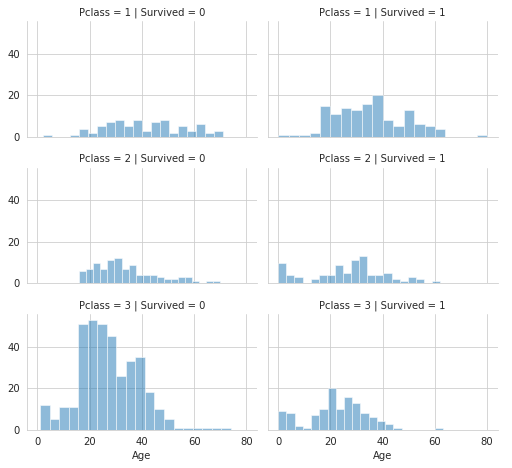

In [76]:
grid = sns.FacetGrid(train_data, col='Survived', row='Pclass', height=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

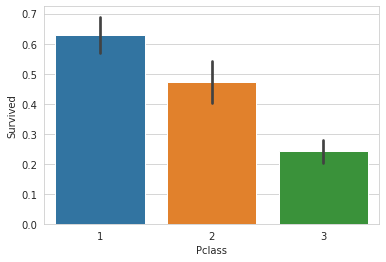

In [77]:
sns.barplot(x='Pclass', y='Survived', data=train_data)

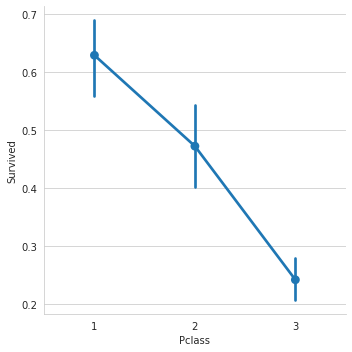

In [78]:
# Pclass

# sns.factorplot('Pclass',data=train_data,kind='count',order=[1,2,3])
sns.factorplot('Pclass','Survived',order=[1,2,3], data=train_data,size=5)

# create dummy variables for Pclass column, & drop 3rd class as it has the lowest average of survived passengers
pclass_dummies_titanic  = pd.get_dummies(train_data['Pclass'])
pclass_dummies_titanic.columns = ['Class_1','Class_2','Class_3']
pclass_dummies_titanic.drop(['Class_3'], axis=1, inplace=True)

pclass_dummies_test  = pd.get_dummies(test_data['Pclass'])
pclass_dummies_test.columns = ['Class_1','Class_2','Class_3']
pclass_dummies_test.drop(['Class_3'], axis=1, inplace=True)

train_data.drop(['Pclass'],axis=1,inplace=True)
test_data.drop(['Pclass'],axis=1,inplace=True)

train_data = train_data.join(pclass_dummies_titanic)
test_data    = test_data.join(pclass_dummies_test)

### Verify no more missing values

In [79]:
print(pd.isnull(train_data).sum())

Survived    0
Age         0
Fare        0
C           0
Q           0
Family      0
Child       0
Female      0
Class_1     0
Class_2     0
dtype: int64


In [80]:
print(pd.isnull(test_data).sum())

PassengerId    0
Age            0
Fare           0
C              0
Q              0
Family         0
Child          0
Female         0
Class_1        0
Class_2        0
dtype: int64


## Make the columns numeric for easier data manipulation

## Create bins by age for Data Visualization

In [81]:
# bins = [0,8,15,18,25,40,60,100]
# names = ['1','2','3','4','5','6','7']
# train_data['Age'] = pd.cut(train_data['Age'],bins,labels=names)
# test_data['Age'] = pd.cut(test_data['Age'],bins,labels=names)

## Verify that the number of rows is correct

In [82]:
print(train_data.shape)

(891, 10)


In [83]:
print(test_data.shape)

(418, 10)


In [84]:
print(train_data.head())

   Survived  Age  Fare  C  Q  Family  Child  Female  Class_1  Class_2
0         0   22     7  0  0       1      0       0        0        0
1         1   38    71  1  0       1      0       1        1        0
2         1   26     7  0  0       0      0       1        0        0
3         1   35    53  0  0       1      0       1        1        0
4         0   35     8  0  0       0      0       0        0        0


In [85]:
print(test_data.head())

   PassengerId  Age  Fare  C  Q  Family  Child  Female  Class_1  Class_2
0          892   34     7  0  1       0      0       0        0        0
1          893   47     7  0  0       1      0       1        0        0
2          894   62     9  0  1       0      0       0        0        1
3          895   27     8  0  0       0      0       0        0        0
4          896   22    12  0  0       1      0       1        0        0


<a id="step2"></a>
# Step 2 Explore Your Options

## Using scikit learn compare different methods and choose the best
- LogisticRegression 
- Support Vector Clustering (SVC)
- KNeighborsClassifier
- RandomForestClassifier

In [86]:
train_data.head()

,Survived,Age,Fare,C,Q,Family,Child,Female,Class_1,Class_2
0,0,22,7,0,0,1,0,0,0,0
1,1,38,71,1,0,1,0,1,1,0
2,1,26,7,0,0,0,0,1,0,0
3,1,35,53,0,0,1,0,1,1,0
4,0,35,8,0,0,0,0,0,0,0


In [87]:
test_data.head()

,PassengerId,Age,Fare,C,Q,Family,Child,Female,Class_1,Class_2
0,892,34,7,0,1,0,0,0,0,0
1,893,47,7,0,0,1,0,1,0,0
2,894,62,9,0,1,0,0,0,0,1
3,895,27,8,0,0,0,0,0,0,0
4,896,22,12,0,0,1,0,1,0,0


In [88]:
# train_test_split
X = np.array(train_data.drop(['Survived'],1))
y = np.array(train_data['Survived'])
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
ids = test_data.PassengerId

## Logistic Regression accuracy score
Logistic Regression % of people who survived: %

In [89]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
score_logreg = model.score(X_train, y_train)
print('Logistic Regression score:', score_logreg)
score_logreg = model.score(X_test, y_test)
print('Logistic Regression score:', score_logreg)
Y_pred = model.predict(test_data.drop('PassengerId',axis=1)) # X_test
out_logreg = pd.DataFrame({'PassengerId':ids,'Survived':Y_pred})
print(out_logreg.head())
people = out_logreg.loc[out_logreg.Survived == 1]["Survived"]
rate_people = 0
if len(people) > 0 :
    rate_people = len(people)/len(out_logreg)
print("Logistic Regression % of people who survived:", rate_people)

Logistic Regression score: 0.8061797752808989
Logistic Regression score: 0.8268156424581006
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Logistic Regression % of people who survived: 0.35645933014354064


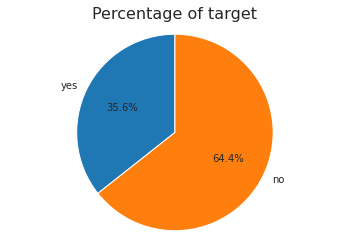

In [90]:
yes = len(people) # len(df[df['target'] == 1])
no = len(out_logreg) - yes # len(df[df['target']== 0])
import matplotlib.pyplot as plt
y = ('yes', 'no')
y_pos = np.arange(len(y))
x = (yes, no)
labels = 'yes', 'no'
sizes = [yes, no]
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%', startangle=90) 
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of target', size=16)
plt.show() # Pie chart, where the slices will be ordered and plotted counter-clockwise:

## Support Vector Clustering accuracy score
Support Vector Clustering % of people who survived: %

In [91]:
model = SVC()
model.fit(X_train, y_train)
score_svc = model.score(X_train, y_train)
print('Support Vector Clustering score: ', score_svc)
score_svc = model.score(X_test, y_test)
print('Support Vector Clustering score: ', score_svc)
Y_pred = model.predict(test_data.drop('PassengerId',axis=1)) # X_test
out_svc = pd.DataFrame({'PassengerId':ids,'Survived':Y_pred})
print(out_svc.head())
people = out_svc.loc[out_svc.Survived == 1]["Survived"]
rate_people = 0
if len(people) > 0 :
    rate_people = len(people)/len(out_svc)
print("Support Vector Clustering % of people who survived:", rate_people)

Support Vector Clustering score:  0.672752808988764
Support Vector Clustering score:  0.659217877094972
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
Support Vector Clustering % of people who survived: 0.16507177033492823


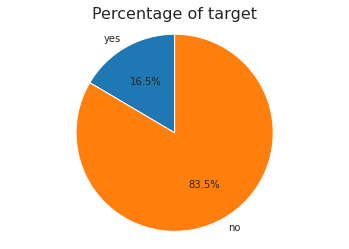

In [92]:
yes = len(people) # len(df[df['target'] == 1])
no = len(out_logreg) - yes # len(df[df['target']== 0])
import matplotlib.pyplot as plt
y = ('yes', 'no')
y_pos = np.arange(len(y))
x = (yes, no)
labels = 'yes', 'no'
sizes = [yes, no]
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%', startangle=90) 
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of target', size=16)
plt.show() # Pie chart, where the slices will be ordered and plotted counter-clockwise:

## KNeighborsClassifier accuracy score
K Neighbors Classifier % of people who survived: %

In [93]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)
score_knc = model.score(X_train, y_train)
print('K Neighbors Classifier score:', score_knc)
score_knc = model.score(X_test, y_test)
print('K Neighbors Classifier score:', score_knc)
Y_pred = model.predict(test_data.drop('PassengerId',axis=1)) # X_test
out_knc = pd.DataFrame({'PassengerId':ids,'Survived':Y_pred})
print(out_knc.head())
people = out_knc.loc[out_knc.Survived == 1]["Survived"]
rate_people = 0
if len(people) > 0 :
    rate_people = len(people)/len(out_knc)
print("K Neighbors Classifier % of people who survived:", rate_people)

K Neighbors Classifier score: 0.7851123595505618
K Neighbors Classifier score: 0.7150837988826816
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
K Neighbors Classifier % of people who survived: 0.3373205741626794


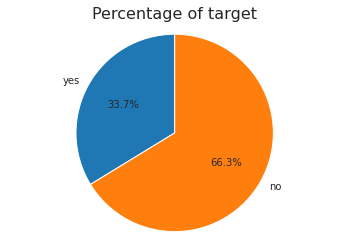

In [94]:
yes = len(people) # len(df[df['target'] == 1])
no = len(out_logreg) - yes # len(df[df['target']== 0])
import matplotlib.pyplot as plt
y = ('yes', 'no')
y_pos = np.arange(len(y))
x = (yes, no)
labels = 'yes', 'no'
sizes = [yes, no]
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%', startangle=90) 
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of target', size=16)
plt.show() # Pie chart, where the slices will be ordered and plotted counter-clockwise:

## RandomForestClassifier accuracy score
Random Forest Classifier % of people who survived: %

In [95]:
model = RandomForestClassifier(n_estimators=100) # , max_depth=5, random_state=1
model.fit(X_train, y_train)
score_rfc = model.score(X_train, y_train)
print('Random Forest Classifier score: ', score_rfc)
score_rfc = model.score(X_test, y_test)
print('Random Forest Classifier score: ', score_rfc)
Y_pred = model.predict(test_data.drop('PassengerId',axis=1)) # X_test
out_rfc = pd.DataFrame({'PassengerId':ids, 'Survived': Y_pred})
print(out_rfc.head())
people = out_rfc.loc[out_rfc.Survived == 1]["Survived"]
rate_people = 0
if len(people) > 0 :
    rate_people = len(people)/len(out_rfc)
print("Random Forest Classifier % of people who survived:", rate_people)

Random Forest Classifier score:  0.9676966292134831
Random Forest Classifier score:  0.8100558659217877
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Random Forest Classifier % of people who survived: 0.3588516746411483


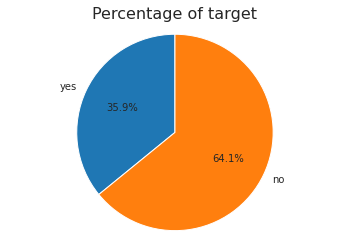

In [96]:
yes = len(people) # len(df[df['target'] == 1])
no = len(out_logreg) - yes # len(df[df['target']== 0])
import matplotlib.pyplot as plt
y = ('yes', 'no')
y_pos = np.arange(len(y))
x = (yes, no)
labels = 'yes', 'no'
sizes = [yes, no]
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%', startangle=90) 
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of target', size=16)
plt.show() # Pie chart, where the slices will be ordered and plotted counter-clockwise:

## DecisionTreeClassifier accuracy score
Decision Tree Classifier % of people who survived: %

In [97]:
decision_tree = DecisionTreeClassifier(max_depth=5) 
decision_tree.fit(X_train, y_train)  
score_dtc = decision_tree.score(X_train, y_train)
print('Decision Tree Classifier score =', score_dtc)
score_dtc = decision_tree.score(X_test, y_test)
print('Decision Tree Classifier score =', score_dtc)
Y_pred = model.predict(test_data.drop('PassengerId',axis=1)) # X_test
out_dtc = pd.DataFrame({'PassengerId':ids, 'Survived': Y_pred})
print(out_dtc.head())
people = out_dtc.loc[out_dtc.Survived == 1]["Survived"]
rate_people = 0
if len(people) > 0 :
    rate_people = len(people)/len(out_dtc)
print("Decision Tree Classifier % of people who survived:", rate_people)

Decision Tree Classifier score = 0.848314606741573
Decision Tree Classifier score = 0.8212290502793296
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Decision Tree Classifier % of people who survived: 0.3588516746411483


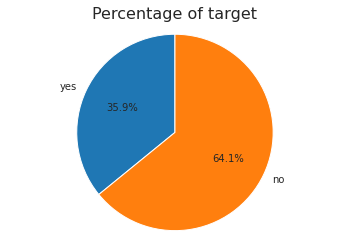

In [98]:
yes = len(people) # len(df[df['target'] == 1])
no = len(out_logreg) - yes # len(df[df['target']== 0])
import matplotlib.pyplot as plt
y = ('yes', 'no')
y_pos = np.arange(len(y))
x = (yes, no)
labels = 'yes', 'no'
sizes = [yes, no]
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%', startangle=90) 
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of target', size=16)
plt.show() # Pie chart, where the slices will be ordered and plotted counter-clockwise:

<a id="step3"></a>
# Step 3 Evaluate The Outcomes

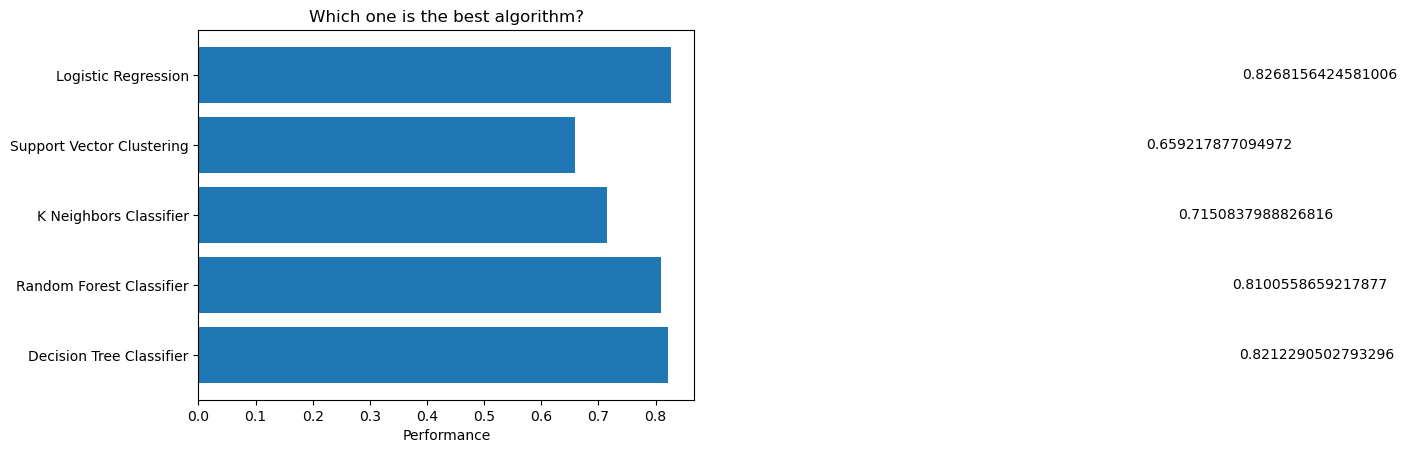

In [99]:
# Fixing random state for reproducibility
plt.rcdefaults()
fig, ax = plt.subplots()
people = ('Logistic Regression', 'Support Vector Clustering', 'K Neighbors Classifier', 'Random Forest Classifier', 'Decision Tree Classifier')
y_pos = np.arange(len(people))
x = (score_logreg,score_svc,score_knc,score_rfc,score_dtc) # scores
ax.barh(y_pos, x, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(people)
ax.invert_yaxis() # labels read top-to-bottom
ax.set_xlabel('Performance')
ax.set_title('Which one is the best algorithm?')
for i, v in enumerate(x):
    ax.text(v + 1, i, str(v), color='black', va='center', fontweight='normal')
plt.show()

In [100]:
score = score_logreg
output = out_logreg
print("Logistic Regression!", score)
if score_svc > score:
    score = score_svc
    output = out_svc
    print("Support Vector Clustering!", score)
if score_knc > score:
    score = score_knc
    output = out_knc
    print("K Neighbors Classifier!", score)
if score_rfc > score:
    score = score_rfc
    output = out_rfc
    print("Random Forest Classifier!", score)
if score_dtc > score:
    score = score_dtc
    output = out_dtc
    print("Decision Tree Classifier!", score)

Logistic Regression! 0.8268156424581006


<a id="step4"></a>
# Step 4 Decide And Act

## Export file my_submission.csv
Upload to kaggle to get a rank in the leaderboard

In [101]:
output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [102]:
output.shape

(418, 2)

In [103]:
output.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [104]:
output.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,0



output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

# <a id="credits"></a>
# Credits
Thanks to my teachers Andrew Ng, Ligdimar González and Isaac Faber

<a id="changelog"></a>
# Change Log
- 2020-08-25 Version 1.0
- 2020-10-05 Table of contents added
- 2021-01-12 Pie chart percentage of survival